In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("StudentsPerformance.csv")
print("First five rows: ")
display(df.head(5))
print("Last five rows: ")
display(df.tail(5))

print("Shape: \n" , df.shape)
print("Info: \n" , df.info())
print("Describe: \n" , df.describe())
print("Null values : " , df.isnull().sum())
print("No null values \n ")


First five rows: 


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


Last five rows: 


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77
999,female,group D,some college,free/reduced,none,77,86,86


Shape: 
 (1000, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB
Info: 
 None
Describe: 
        math score  reading score  writing score
count  1000.00000    1000.000000    1000.000000
mean     66.08900      69.169000      68.054000
std      15.16308      14.600192      15.195657
min       0.00000      17.000000      

In [3]:
print("male and female students: \n" , df["gender"].value_counts() )
print("race/ethnicity count: \n" , df["race/ethnicity"].value_counts() )
print("Test preparation course distribution:\n", df["test preparation course"].value_counts())
print("Average math score: " , df["math score"].mean())
print("Average reading score: " , df["reading score"].mean())
print("Average writing score: " , df["writing score"].mean())
genderperformance = df.groupby('gender')[['math score', 'reading score', 'writing score']].mean()
display(genderperformance)


male and female students: 
 gender
female    518
male      482
Name: count, dtype: int64
race/ethnicity count: 
 race/ethnicity
group C    319
group D    262
group B    190
group E    140
group A     89
Name: count, dtype: int64
Test preparation course distribution:
 test preparation course
none         642
completed    358
Name: count, dtype: int64
Average math score:  66.089
Average reading score:  69.169
Average writing score:  68.054


,math score,reading score,writing score
gender,,,
female,63.633205,72.608108,72.467181
male,68.728216,65.473029,63.311203


In [6]:
display("math score > 90 : " , df["math score"  ] > 90 )

display("scores > 80 " , (df["math score"] > 80) & (df["reading score"] > 80) & (df["writing score"] > 80))

females_with_high_reading = (df["gender"] == "female") & (df["reading score"] > 85)
print("Female students with reading score > 85:")
display(females_with_high_reading)

notcompletedcourse = (df["test preparation course"] == "none")
print("Students who did not complete the test preparation course:")
display(notcompletedcourse)

lunchtype = (df['lunch'] == "standard")
display("students with standard lunch type: " , lunchtype)

'math score > 90 : '

,math score
0,False
1,False
2,False
3,False
4,False
...,...
995,False
996,False
997,False
998,False


'scores > 80 '

,0
0,False
1,False
2,True
3,False
4,False
...,...
995,True
996,False
997,False
998,False


Female students with reading score > 85:


,0
0,False
1,True
2,True
3,False
4,False
...,...
995,True
996,False
997,False
998,False


Students who did not complete the test preparation course:


,test preparation course
0,True
1,False
2,True
3,True
4,True
...,...
995,False
996,True
997,False
998,False


'students with standard lunch type: '

,lunch
0,True
1,True
2,True
3,False
4,True
...,...
995,True
996,False
997,False
998,True


In [7]:
df["average_score"] = (df["math score"] + df["reading score"] + df["writing score"]) / 3

print("Top 10 average scores:")
display(df["average_score"].sort_values(ascending=False).head(10))

import numpy as np
df["result"] = np.where( df["average_score"] >= 50 , "Pass" , "Fail")
display(df["result"])

bins = [0, 50, 60, 70, 80, 100]
labels = ['F', 'D', 'C', 'B', 'A']

df['Grade'] = pd.cut(df['average_score'], bins=bins, labels=labels, right=False)

print("Grades:")
display(df["Grade"])
print("Grade distribution:")
display(df['Grade'].value_counts().sort_index(ascending=False))

Top 10 average scores:


,average_score
916,100.000000
962,100.000000
458,100.000000
114,99.666667
712,99.000000
179,99.000000
165,98.666667
625,98.666667
685,97.666667
903,97.666667


,result
0,Pass
1,Pass
2,Pass
3,Fail
4,Pass
...,...
995,Pass
996,Pass
997,Pass
998,Pass


Grades:


,Grade
0,B
1,A
2,A
3,F
4,B
...,...
995,A
996,D
997,C
998,B


Grade distribution:


,count
Grade,
A,195
B,261
C,256
D,182
F,103


In [8]:
scorebygender = df.groupby("gender")["average_score"].mean()
display(scorebygender)

scorebyprep = df.groupby("test preparation course")["average_score"].mean()
display(scorebyprep)

avgmathscore = df.groupby("parental level of education")["math score"].mean()
display(avgmathscore)

avgreading = df.groupby("parental level of education")["reading score"].mean()
display(avgreading)

avgscorebylunch = df.groupby("lunch")["average_score"].mean()
display(avgscorebylunch)

avgscorebyrace = df.groupby("race/ethnicity")["average_score"].mean()
display(avgscorebyrace)


,average_score
gender,
female,69.569498
male,65.837483


,average_score
test preparation course,
completed,72.669460
none,65.038941


,math score
parental level of education,
associate's degree,67.882883
bachelor's degree,69.389831
high school,62.137755
master's degree,69.745763
some college,67.128319
some high school,63.497207


,reading score
parental level of education,
associate's degree,70.927928
bachelor's degree,73.000000
high school,64.704082
master's degree,75.372881
some college,69.460177
some high school,66.938547


,average_score
lunch,
free/reduced,62.199061
standard,70.837209


,average_score
race/ethnicity,
group A,62.992509
group B,65.468421
group C,67.131661
group D,69.179389
group E,72.752381


In [10]:
top10bymathscore = df.nlargest(10, "math score")
print("top 10 by maths score: ")
display(top10bymathscore)

top10byreadingscore = df.nlargest(10, "reading score")
print("top 10 by reading score: ")
display(top10byreadingscore)

top10byavgscore = df.nlargest(10, "average_score")
print("top 10 by average score: ")
display(top10byavgscore)

lowest10bywritingscore = df.nsmallest(10, "writing score")
print("lowest 10 by writing score: ")
display(lowest10bywritingscore)

top 10 by maths score: 


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average_score,result,Grade
149,male,group E,associate's degree,free/reduced,completed,100,100,93,97.666667,Pass,A
451,female,group E,some college,standard,none,100,92,97,96.333333,Pass,A
458,female,group E,bachelor's degree,standard,none,100,100,100,100.000000,Pass,NaN
623,male,group A,some college,standard,completed,100,96,86,94.000000,Pass,A
625,male,group D,some college,standard,completed,100,97,99,98.666667,Pass,A
916,male,group E,bachelor's degree,standard,completed,100,100,100,100.000000,Pass,NaN
962,female,group E,associate's degree,standard,none,100,100,100,100.000000,Pass,NaN
114,female,group E,bachelor's degree,standard,completed,99,100,100,99.666667,Pass,A
263,female,group E,high school,standard,none,99,93,90,94.000000,Pass,A
306,male,group E,some college,standard,completed,99,87,81,89.000000,Pass,A


top 10 by reading score: 


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average_score,result,Grade
106,female,group D,master's degree,standard,none,87,100,100,95.666667,Pass,A
114,female,group E,bachelor's degree,standard,completed,99,100,100,99.666667,Pass,A
149,male,group E,associate's degree,free/reduced,completed,100,100,93,97.666667,Pass,A
165,female,group C,bachelor's degree,standard,completed,96,100,100,98.666667,Pass,A
179,female,group D,some high school,standard,completed,97,100,100,99.000000,Pass,A
381,male,group C,associate's degree,standard,completed,87,100,95,94.000000,Pass,A
458,female,group E,bachelor's degree,standard,none,100,100,100,100.000000,Pass,NaN
546,female,group A,some high school,standard,completed,92,100,97,96.333333,Pass,A
566,female,group E,bachelor's degree,free/reduced,completed,92,100,100,97.333333,Pass,A
594,female,group C,bachelor's degree,standard,completed,92,100,99,97.000000,Pass,A


top 10 by average score: 


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average_score,result,Grade
458,female,group E,bachelor's degree,standard,none,100,100,100,100.000000,Pass,NaN
916,male,group E,bachelor's degree,standard,completed,100,100,100,100.000000,Pass,NaN
962,female,group E,associate's degree,standard,none,100,100,100,100.000000,Pass,NaN
114,female,group E,bachelor's degree,standard,completed,99,100,100,99.666667,Pass,A
179,female,group D,some high school,standard,completed,97,100,100,99.000000,Pass,A
712,female,group D,some college,standard,none,98,100,99,99.000000,Pass,A
165,female,group C,bachelor's degree,standard,completed,96,100,100,98.666667,Pass,A
625,male,group D,some college,standard,completed,100,97,99,98.666667,Pass,A
149,male,group E,associate's degree,free/reduced,completed,100,100,93,97.666667,Pass,A
685,female,group E,master's degree,standard,completed,94,99,100,97.666667,Pass,A


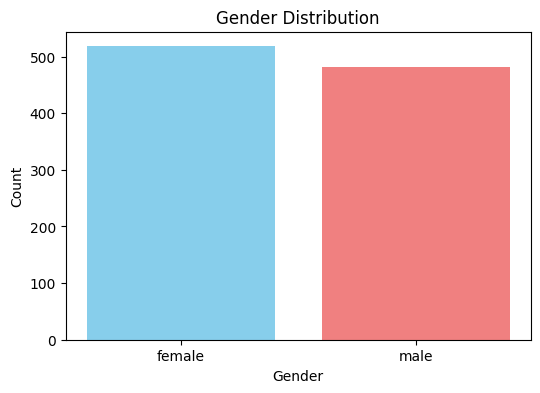

In [13]:
gender_counts = df["gender"].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(gender_counts.index, gender_counts.values, color=['skyblue', 'lightcoral'])
plt.xlabel("Gender")
plt.ylabel("Count")
plt.title("Gender Distribution")
plt.show()

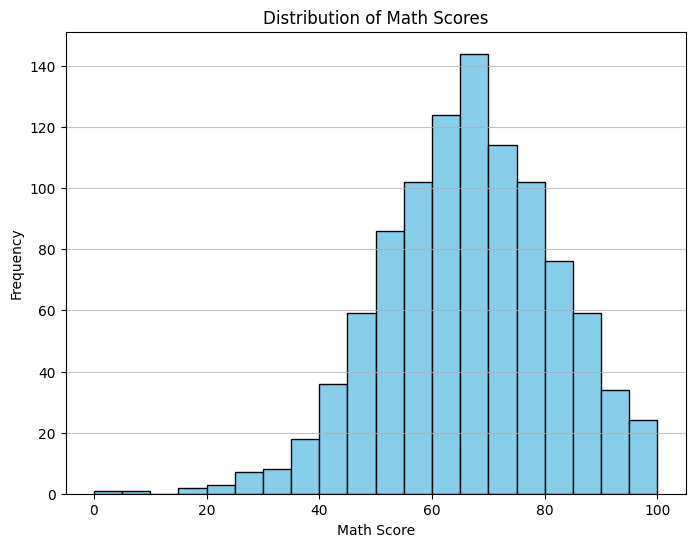

In [14]:
plt.figure(figsize=(8, 6))
plt.hist(df['math score'], bins=20, color='skyblue', edgecolor='black')
plt.xlabel('Math Score')
plt.ylabel('Frequency')
plt.title('Distribution of Math Scores')
plt.grid(axis='y', alpha=0.75)
plt.show()

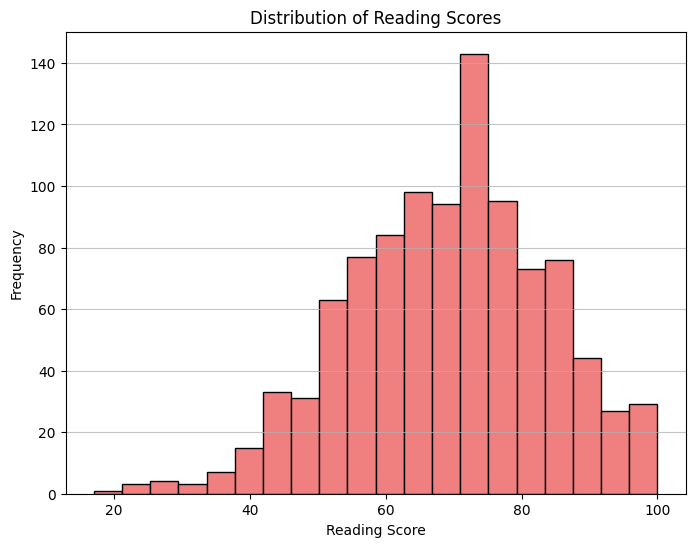

In [15]:
plt.figure(figsize=(8, 6))
plt.hist(df['reading score'], bins=20, color='lightcoral', edgecolor='black')
plt.xlabel('Reading Score')
plt.ylabel('Frequency')
plt.title('Distribution of Reading Scores')
plt.grid(axis='y', alpha=0.75)
plt.show()

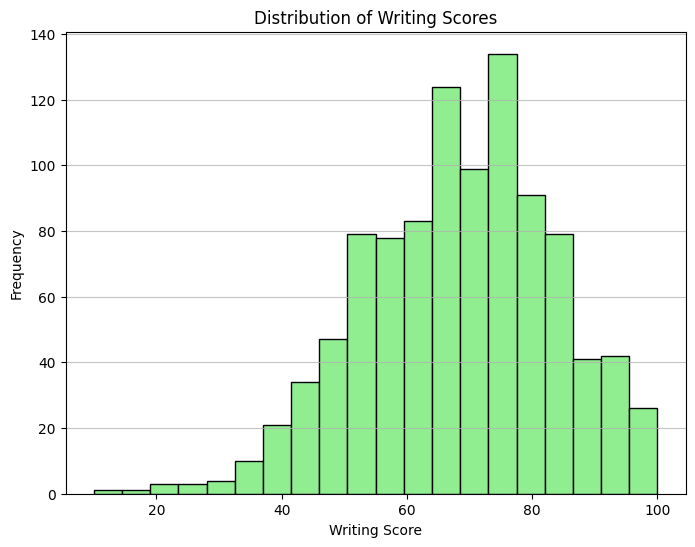

In [16]:
plt.figure(figsize=(8, 6))
plt.hist(df['writing score'], bins=20, color='lightgreen', edgecolor='black')
plt.xlabel('Writing Score')
plt.ylabel('Frequency')
plt.title('Distribution of Writing Scores')
plt.grid(axis='y', alpha=0.75)
plt.show()

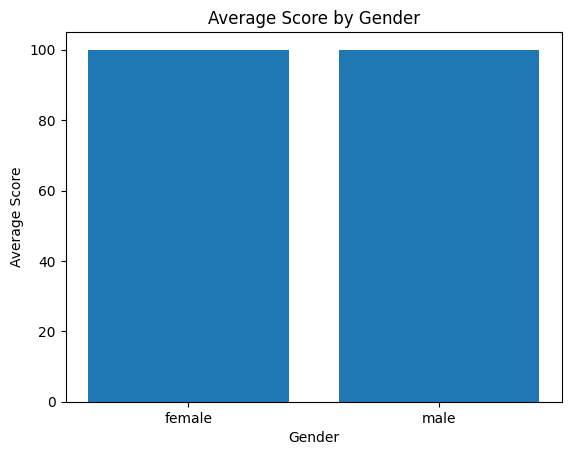

In [17]:
plt.bar(df["gender"], df["average_score"])
plt.xlabel("Gender")
plt.ylabel("Average Score")
plt.title("Average Score by Gender")
plt.show()

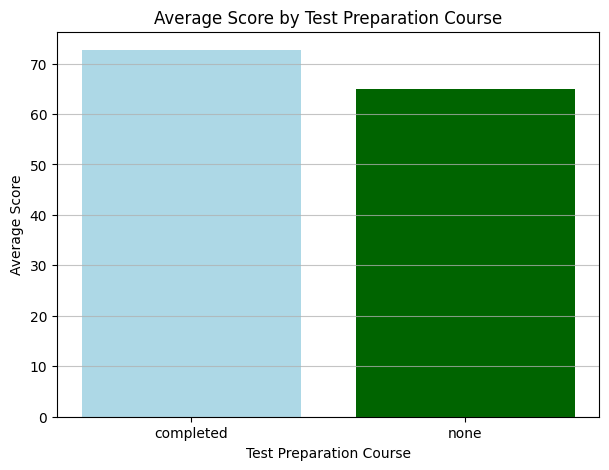

In [19]:
plt.figure(figsize=(7, 5))
plt.bar(scorebyprep.index, scorebyprep.values, color=['lightblue', 'darkgreen'])
plt.xlabel('Test Preparation Course')
plt.ylabel('Average Score')
plt.title('Average Score by Test Preparation Course')
plt.grid(axis='y', alpha=0.75)
plt.show()

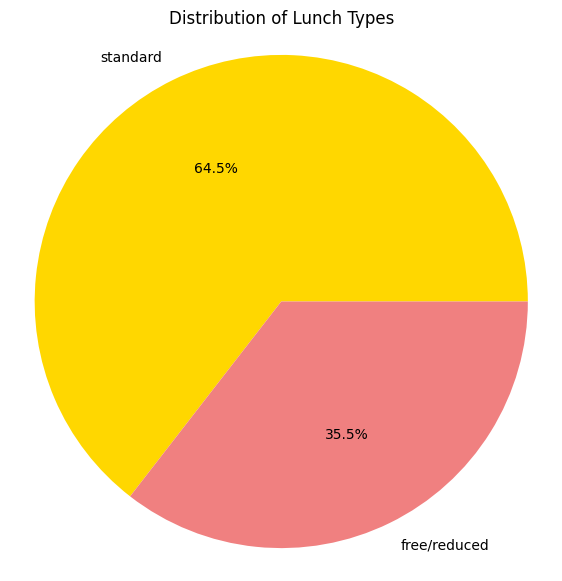

In [21]:
lunchcounts = df['lunch'].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(lunchcounts, labels=lunchcounts.index, autopct='%1.1f%%', colors=['gold', 'lightcoral'])
plt.title('Distribution of Lunch Types')
plt.axis('equal')
plt.show()

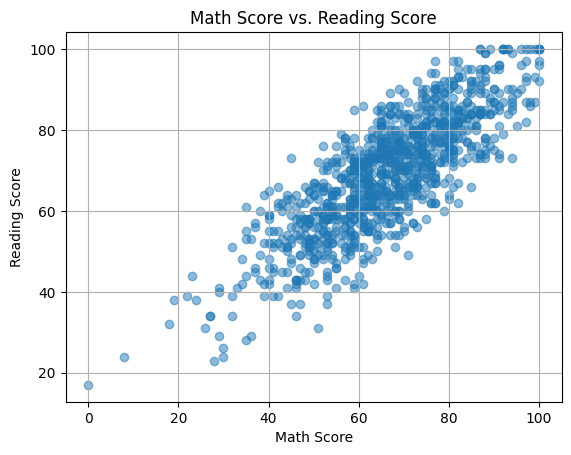

In [22]:
plt.scatter(df['math score'], df['reading score'], alpha=0.5)
plt.xlabel('Math Score')
plt.ylabel('Reading Score')
plt.title('Math Score vs. Reading Score')
plt.grid(True)

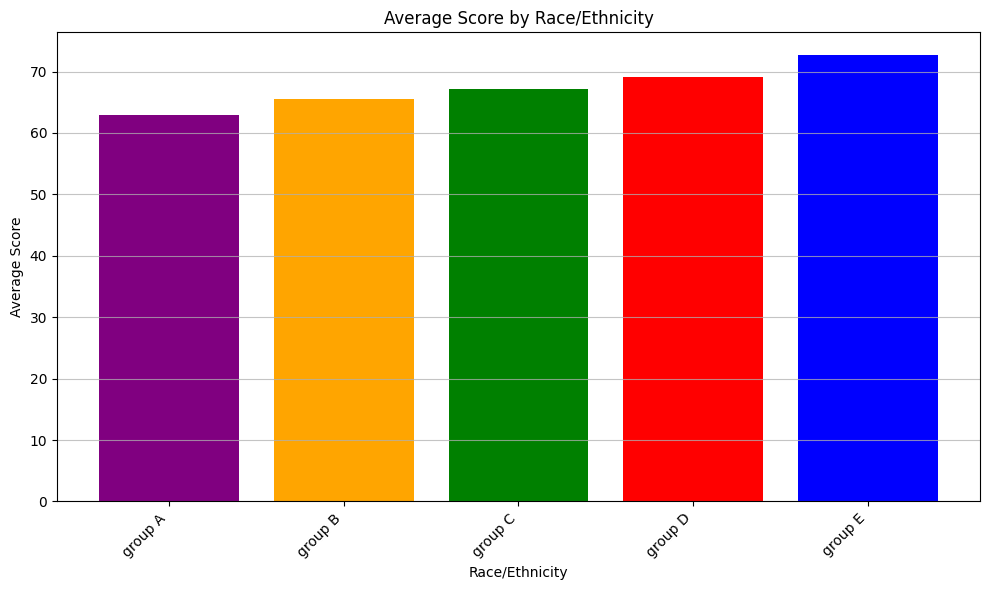

In [23]:
plt.figure(figsize=(10, 6))
plt.bar(avgscorebyrace.index, avgscorebyrace.values, color=['purple', 'orange', 'green', 'red', 'blue'])
plt.xlabel('Race/Ethnicity')
plt.ylabel('Average Score')
plt.title('Average Score by Race/Ethnicity')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

In [24]:
top5genius = df.sort_values(by="average_score", ascending=False).head(5)
print("Top 5 Genius Students:")
display(top5genius)

Top 5 Genius Students:


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average_score,result,Grade
916,male,group E,bachelor's degree,standard,completed,100,100,100,100.000000,Pass,NaN
962,female,group E,associate's degree,standard,none,100,100,100,100.000000,Pass,NaN
458,female,group E,bachelor's degree,standard,none,100,100,100,100.000000,Pass,NaN
114,female,group E,bachelor's degree,standard,completed,99,100,100,99.666667,Pass,A
712,female,group D,some college,standard,none,98,100,99,99.000000,Pass,A


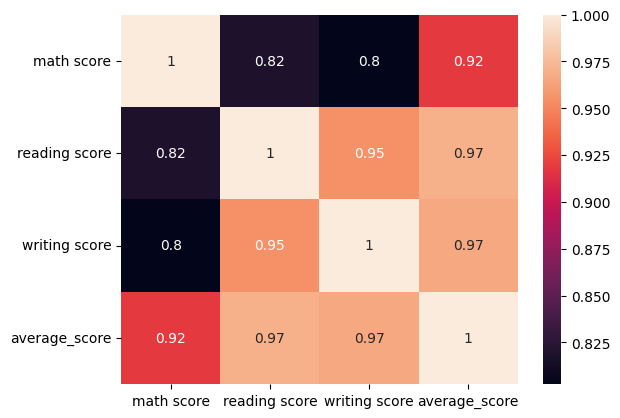

In [26]:
import seaborn as sns
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True)
plt.show()